# Build a model to predict Koc 

The aim of this assignment is to build a model that can predict the soil sorption coefficient logKoc. In contrast to the previous assignment, this time the goal is outperform the state-of-the-art OPERA Koc model:

 - Paper on OPERA models, including the one for Koc: https://doi.org/10.1186/s13321-018-0263-1
 - Performance of the OPERA Koc model on the test set: R2 = 0.71, RMSE = 0.61
 - Model: weighted k-Nearest Neighbors regressor trained on 12 selected PaDEL descriptors (similar to RDKit descriptors)

As you are now a modelling expert, it is open to you which model architecture you use. BUT we ask you to justify your choices! 


#### Tasks:

1) Load the training data and split it into train and test according to the 'Tr_1_Tst_0' column

2) Think about a suitable architecture:
    - Suitable descriptors/fingerprints
    - Model choice (fine-tune a pretrained neural network? GNN? Ensemble method? Gaussian Process? ...?)
    - Consider providing an AD for your model (using an AD metric, or by defining the content of the training data (e.g., organic chemicals with a MW between x and y)
    - Consider providing prediction uncertainty: If you decide to do so, provide uncertainty calibration. If not, explain why.
    
        
3) Train the model on the same training data used in the paper (Tr_1_Tst_0 == 1). 

4) Consider tuning hyperparameters (e.g., using GridSearchCV and on a short list of parameters) 

5) Evaluate model on the test set (Tr_1_Tst_0 == 0), ONLY ONCE ! 

6) Compare your model performance on the test set to the OPERA model. 

#### Questions:
1) Which architecture did you choose, and why?
2) How well does your model perform on the test set? Could you outperform OPERA?
3) Did you add prediction uncertainty, and why? Are the uncertainties well calibrated?
4) Do you provide an AD, and why? How did you define your AD


In [14]:
# import
import pandas as pd
import numpy as np
from rdkit import Chem
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor, NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.isotonic import IsotonicRegression

import matplotlib.pyplot as plt


#### 1. Load training data

In [4]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("/Users/hassanhaydar/DSA104/assignments/assignment10/KOC_QR.sdf")
df = pd.DataFrame([
    {
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    }
    for m in supplier if m is not None
])

In [6]:
# Loading the data from the .sdf file
supplier = Chem.SDMolSupplier("/Users/hassanhaydar/DSA104/assignments/assignment10/KOC_QR.sdf")

records = []
for m in supplier:
    if m is None:
        continue
    records.append({
        "mol": m,
        "SMILES": Chem.MolToSmiles(m),
        **{p: m.GetProp(p) for p in ['preferred_name', 'LogKOC', 'Tr_1_Tst_0']}
    })

df = pd.DataFrame(records)
df["LogKOC"]    = df["LogKOC"].astype(float)
df["Tr_1_Tst_0"] = df["Tr_1_Tst_0"].astype(int)

print(f"Total molecules: {len(df)}")
print(df.groupby('Tr_1_Tst_0')[['LogKOC']].agg(['count', 'mean', 'std']))

Total molecules: 728
           LogKOC                    
            count      mean       std
Tr_1_Tst_0                           
0             184  2.592092  1.146003
1             544  2.724540  1.253070


In [7]:
# The data is pre-split in training and testing:
df.groupby('Tr_1_Tst_0').count()

,mol,SMILES,preferred_name,LogKOC
Tr_1_Tst_0,,,,
0,184,184,184,184
1,544,544,544,544


#### 2. Build a supervised model of your choice

In [11]:
from rdkit.Chem import Descriptors, AllChem
# Encoding molecules from SMILES
desc_names = [n for n, _ in Descriptors.descList]

def featurise(mol):
    """Return a 1D numpy array: Morgan bits (2048) + RDKit descriptors."""
    # ECFP4 fingerprint
    gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
    fp = np.array(gen.GetFingerprint(mol))
    # RDKit 2D descriptors
    desc_vals = []
    for n in desc_names:
        try:
            v = Descriptors.__dict__[n](mol)
            desc_vals.append(float(v) if v is not None else 0.0)
        except Exception:
            desc_vals.append(0.0)
    return np.concatenate([fp, desc_vals])

X_all = np.array([featurise(r.mol) for r in df.itertuples()])
y_all = df.LogKOC.values
X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Feature matrix: {X_all.shape}")

Feature matrix: (728, 2265)


In [12]:
train_mask = df.Tr_1_Tst_0.values == 1
test_mask  = df.Tr_1_Tst_0.values == 0

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_test,  y_test  = X_all[test_mask],  y_all[test_mask]

print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")

Train: 544  |  Test: 184


PCA retained 336 components (95.0% variance)


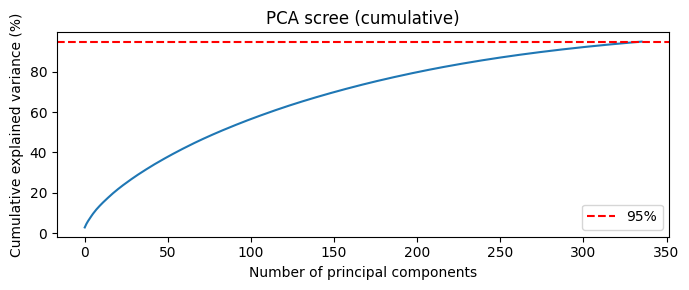

In [16]:
#PCA
scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

pca = PCA(n_components=0.95, svd_solver='full', random_state=42)
X_tr_pca = pca.fit_transform(X_tr_sc)
X_te_pca = pca.transform(X_te_sc)

print(f"PCA retained {pca.n_components_} components "
      f"({pca.explained_variance_ratio_.sum()*100:.1f}% variance)")

plt.figure(figsize=(7,3))
plt.plot(np.cumsum(pca.explained_variance_ratio_)*100, lw=1.5)
plt.axhline(95, color='r', ls='--', label='95%')
plt.xlabel('Number of principal components'); plt.ylabel('Cumulative explained variance (%)')
plt.title('PCA scree (cumulative)'); 
plt.legend()
plt.tight_layout()
plt.show()

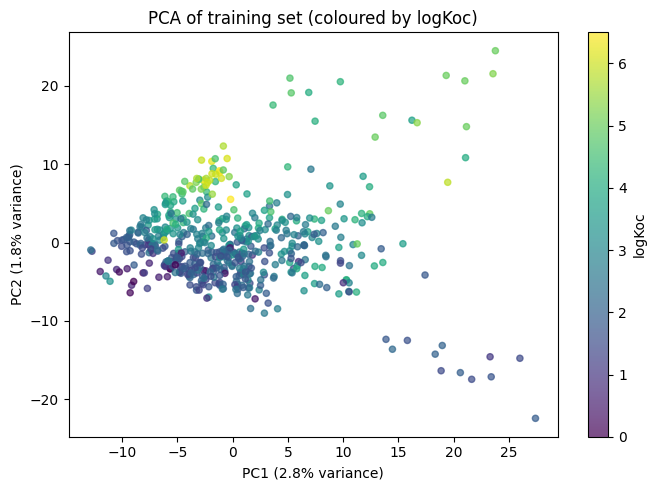

PC1 + PC2 explain 4.5% of total variance


In [ ]:
# PCA Visualization (2D)
pca_vis = PCA(n_components=2, random_state=42)
X_tr_2d = pca_vis.fit_transform(X_tr_sc)

plt.figure(figsize=(7, 5))
sc = plt.scatter(X_tr_2d[:, 0], X_tr_2d[:, 1],
                 c=y_train, cmap='viridis', s=20, alpha=0.7)
plt.colorbar(sc, label='logKoc')
plt.xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA of training set (coloured by logKoc)')
plt.tight_layout()
plt.show()

print(f"PC1 + PC2 explain {pca_vis.explained_variance_ratio_.sum()*100:.1f}% of total variance")

In [26]:
# Model
rf = RandomForestRegressor(
    n_estimators=300,
    max_features='sqrt',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_tr_pca, y_train)

# Collect per-tree predictions for uncertainty
tree_preds_train = np.array([t.predict(X_tr_pca) for t in rf.estimators_])
tree_preds_test  = np.array([t.predict(X_te_pca)  for t in rf.estimators_])

rf_pred_train = tree_preds_train.mean(axis=0)
rf_pred_test  = tree_preds_test.mean(axis=0)
rf_std_test   = tree_preds_test.std(axis=0)   # raw inter-tree std

rf_r2_train  = r2_score(y_train, rf_pred_train)
print(f"RF train R² = {rf_r2_train:.3f}")

RF train R² = 0.923


In [19]:
param_grid = {'n_neighbors': [3, 5, 7, 10, 15]}
knn_gs = GridSearchCV(
    KNeighborsRegressor(weights='distance', metric='euclidean'),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
knn_gs.fit(X_tr_pca, y_train)

best_k = knn_gs.best_params_['n_neighbors']
cv_r2  = knn_gs.best_score_
print(f"Best k = {best_k}  |  CV R² = {cv_r2:.3f}")
knn = knn_gs.best_estimator_

Best k = 5  |  CV R² = 0.529


#### 3. Model performance on test set
--> **TEST ONLY ONCE !**

In [23]:
# Scale PCA output (required for KDE)
pca_scaler = StandardScaler()
X_tr_pca_scaled = pca_scaler.fit_transform(X_tr_pca)
X_te_pca_scaled = pca_scaler.transform(X_te_pca)

Best KDE bandwidth: 0.5
AD threshold = -8.547
Test in AD: 126 / 184  (68.5%)


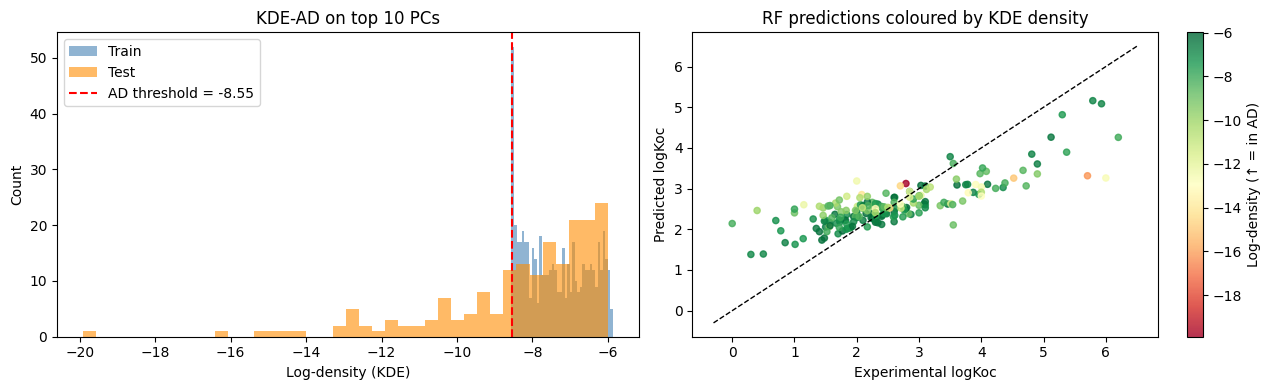


RF R²   inside  AD: 0.678  (126 compounds)
RF R²   outside AD: 0.291  (58 compounds)
RF RMSE inside  AD: 0.660
RF RMSE outside AD: 0.916


In [ ]:

# KDE only works in low dimensions used top 10 PCs (most variance)
N_COMPONENTS_KDE = 10

X_tr_kde = X_tr_pca_scaled[:, :N_COMPONENTS_KDE]
X_te_kde = X_te_pca_scaled[:, :N_COMPONENTS_KDE]

# Tune bandwidth
bandwidth_grid = {'bandwidth': [0.5, 1.0, 2.0, 5.0, 10.0]}
kde_cv = GridSearchCV(KernelDensity(kernel='gaussian'),
                      bandwidth_grid, cv=5)
kde_cv.fit(X_tr_kde)
best_bw = kde_cv.best_params_['bandwidth']
print(f"Best KDE bandwidth: {best_bw}")

# Fit KDE
kde = KernelDensity(kernel='gaussian', bandwidth=best_bw)
kde.fit(X_tr_kde)

train_log_density = kde.score_samples(X_tr_kde)
test_log_density  = kde.score_samples(X_te_kde)

# AD threshold = 5th percentile of training density
ad_threshold_kde = np.percentile(train_log_density, 5)
in_ad_kde  = test_log_density >= ad_threshold_kde
out_ad_kde = ~in_ad_kde

print(f"AD threshold = {ad_threshold_kde:.3f}")
print(f"Test in AD: {in_ad_kde.sum()} / {len(in_ad_kde)}  ({in_ad_kde.mean():.1%})")

#Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(train_log_density, bins=40, alpha=0.6, label='Train', color='steelblue')
ax.hist(test_log_density,  bins=40, alpha=0.6, label='Test',  color='darkorange')
ax.axvline(ad_threshold_kde, color='red', ls='--',
           label=f'AD threshold = {ad_threshold_kde:.2f}')
ax.set_xlabel('Log-density (KDE)')
ax.set_ylabel('Count')
ax.set_title(f'KDE-AD on top {N_COMPONENTS_KDE} PCs')
ax.legend()

ax = axes[1]
sc = ax.scatter(y_test, rf_pred_test,
                c=test_log_density, cmap='RdYlGn', s=20, alpha=0.8)
plt.colorbar(sc, ax=ax, label='Log-density (↑ = in AD)')
lims = [min(y_test.min(), rf_pred_test.min()) - 0.3,
        max(y_test.max(), rf_pred_test.max()) + 0.3]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlabel('Experimental logKoc')
ax.set_ylabel('Predicted logKoc')
ax.set_title('RF predictions coloured by KDE density')
plt.tight_layout()
plt.show()

# Performance inside vs outside AD
print(f"\nRF R²   inside  AD: {r2_score(y_test[in_ad_kde],  rf_pred_test[in_ad_kde]):.3f}  ({in_ad_kde.sum()} compounds)")
print(f"RF R²   outside AD: {r2_score(y_test[out_ad_kde], rf_pred_test[out_ad_kde]):.3f}  ({out_ad_kde.sum()} compounds)")
print(f"RF RMSE inside  AD: {np.sqrt(mean_squared_error(y_test[in_ad_kde],  rf_pred_test[in_ad_kde])):.3f}")
print(f"RF RMSE outside AD: {np.sqrt(mean_squared_error(y_test[out_ad_kde], rf_pred_test[out_ad_kde])):.3f}")